In [1]:
from utils import *
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from copy import copy
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
import torch
torch.backends.cudnn.benchmark = True
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

import segmentation_models_pytorch as smp
import argus
from argus.callbacks import MonitorCheckpoint, EarlyStopping, LoggingToFile, ReduceLROnPlateau
import albumentations as A
from pytorch_toolbelt.inference.tiles import ImageSlicer, CudaTileMerger
from pytorch_toolbelt.losses import LovaszLoss

In [3]:
train, labels, test = importData('data/data_train.npz','data/labels_train.npz','data/data_test_1.npz')
labels -= 1

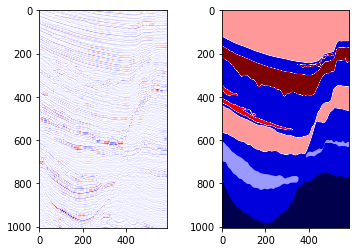

In [3]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(train[:,380,:],cmap='seismic')

axs[1].imshow(labels[:,380,:],cmap='seismic')
plt.show()

 ## Normalization with respect to the test data

In [4]:
adjusted_test_img = np.concatenate([train, test], axis=2)

_min, _max = adjusted_test_img.min(), adjusted_test_img.max()

train = (train - _min) / (_max - _min)
test = (test - _min) / (_max - _min)
adjusted_test_img = (adjusted_test_img - _min) / (_max - _min)

del adjusted_test_img

## Split data into train and test since the submission website is down

In [5]:
X_train, X_test, y_train, y_test = train_test_split(train.transpose(2,0,1), labels.transpose(2,0,1),test_size=0.33, random_state=42)
X_train, X_test, y_train, y_test = X_train.transpose(1,2,0), X_test.transpose(1,2,0), y_train.transpose(1,2,0), y_test.transpose(1,2,0)

In [6]:
del test
del train

## Create K-folds index from every possible vertical slice (Z,X and Z,Y)

In [7]:
verticals = [0 for _ in range(X_train.shape[1])] + [1 for _ in range(X_train.shape[2])]
folds = list(StratifiedKFold(n_splits=5, random_state=42, shuffle=True).split(X=verticals, y=verticals))

In [6]:
img = train[:,5]
img800 = train[:,:,800-482]
print(img.shape)
image = img[:, :, None]
print(image.shape)
tran = image.transpose(2,0,1)
print(tran.shape)

(1006, 590)
(1006, 590, 1)
(1, 1006, 590)


## Dataset class

In [8]:
class SeismicFaciesDataset(Dataset):
    def __init__(self, img, labels, train=True):
        self.img = img
        self.labels = labels
        self.xaxis = self.img.shape[1]
        self.yaxis = self.img.shape[2]

        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(p=0.7, shift_limit=0, scale_limit=0.15, rotate_limit=15),
            A.RandomCrop(p=1, height=896, width=256),
        ])

    def __len__(self):
        return self.xaxis + self.yaxis

    def __getitem__(self, idx):
        if idx < self.xaxis:
            image, mask = self.img[:, idx], self.labels[:, idx]
        else:
            image, mask = self.img[:, :, idx-self.xaxis], self.labels[:, :, idx-self.xaxis]

        image = image[:, :, None]

        augmented = self.aug(image=image, mask=mask)
        image, mask = augmented['image'], augmented['mask']

        return image.transpose(2, 0, 1), mask


### HomeMade function to get data using DataLoader

In [9]:
def get_data_loaders(dataset, batch_size, train_index, test_index):
    train_dataset, test_dataset = Subset(dataset, train_index), Subset(copy(dataset), test_index)
    test_dataset.dataset.aug = A.PadIfNeeded(p=1, min_height=1024, min_width=800)


    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=1, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=1)
    return train_loader, test_loader


## Model

### Loss model (to change maybe)

In [10]:
class LovaszBCELoss(torch.nn.Module):
    def __init__(self, lovasz_weight=0.75, ce_weight=0.25):
        super().__init__()
        self.lovasz_weight = lovasz_weight
        self.ce_weight = ce_weight
        self.ce = torch.nn.CrossEntropyLoss()
        self.lovasz = LovaszLoss()

    def forward(self, output, target):
        if self.lovasz_weight > 0:
            lovasz = self.lovasz(torch.softmax(output, dim=1), target) * self.lovasz_weight
        else:
            lovasz = 0

        if self.ce_weight > 0:
            ce = self.ce(output, target.long()) * self.ce_weight
        else:
            ce = 0

        return lovasz + ce

### Model based on argus

In [11]:
class SeismicFaciesModel(argus.Model):
    nn_module = smp.Unet
    optimizer = optim.SGD
    loss = LovaszBCELoss

In [12]:
params = {
    'nn_module': {
        'encoder_depth': 3,
        'decoder_channels': [128,64,32],
        'encoder_name': 'efficientnet-b2',
        'decoder_attention_type': 'scse',
        'classes': 6,
        'in_channels': 1,
        'activation': None
    },
    'loss': {
        'lovasz_weight': 0.75,
        'ce_weight': 0.25,
    },
    'optimizer': {'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0001},
    'device': 'cuda'
}

## Training

In [13]:
dataset = SeismicFaciesDataset(X_train, y_train)

In [49]:
for i, (train_index, test_index) in enumerate(folds):
    print(i)
    model = SeismicFaciesModel(params)
    model.set_device(0)

    train_loader, val_loader = get_data_loaders(dataset, batch_size=1, train_index=train_index, test_index=test_index)

    callbacks = [
        MonitorCheckpoint(dir_path=f'unet_fold_{i}', monitor='val_loss', max_saves=3),
        ReduceLROnPlateau(monitor='val_loss', patience=30, factor=0.64, min_lr=1e-8),
        EarlyStopping(monitor='val_loss', patience=50),
        LoggingToFile(f'unet_fold_{i}.log'),
    ]

    model.fit(train_loader,
          val_loader=val_loader,
          num_epochs=50,
          metrics=['loss'],
          callbacks=callbacks,
          metrics_on_train=False)

0
[2020-11-15 12:30:39,721][ERROR]: [Errno 32] Broken pipe
Traceback (most recent call last):
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\argus\engine\engine.py", line 82, in run
    for batch in data_loader:
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 352, in __iter__
    return self._get_iterator()
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 294, in _get_iterator
    return _MultiProcessingDataLoaderIter(self)
  File "c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\torch\utils\data\dataloader.py", line 801, in __init__
    w.start()
  File "C:\Users\arno\AppData\Local\Programs\Python\Python37\lib\multiprocessing\process.py", line 112, in start
    self._popen = self._Popen(self)
  File "C:\Users\arno\AppData\Local\Programs\Python\Py

BrokenPipeError: [Errno 32] Broken pipe

In [14]:
print('start prediction')
model = argus.load_model('unet_fold_0\model-692-0.053404.pth',device=0)
print('model loaded')

start prediction
model loaded


## Predict on the test data from the split of train

In [17]:
tiler = ImageSlicer(X_train.shape[:-1] + (1,), tile_size=(896, 256),tile_step=(40,40))
merger = CudaTileMerger(tiler.target_shape, 6, tiler.weight)

test_labels = []
i=0
for img in X_test.transpose(2, 0, 1):
    tiles = [tile for tile in tiler.split(img[:, :, None])]
    print(i/251)
    for tiles_batch, coords_batch in DataLoader(list(zip(tiles, tiler.crops)), batch_size=4):
        # print(len(tiles_batch))
        # print('a')
        tiles_batch = tiles_batch.permute(0, 3, 1, 2)
        # print('b')
        pred_batch = torch.softmax(model.predict(tiles_batch), axis=1)
        # print('c')
        merger.integrate_batch(pred_batch, coords_batch)
        # print('d')
    merged_mask = merger.merge()
    merged_mask = merged_mask.permute(1, 2, 0).cpu().numpy()
    merged_mask = tiler.crop_to_orignal_size(merged_mask).argmax(2)
    test_labels.append(merged_mask)
    i+=1

test_labels = np.stack(test_labels).transpose(1, 2, 0)

print('finish pred, start to save')

np.savez_compressed(
    'prediction_small.npz',
    prediction=test_labels.astype(labels.dtype) + 1
)

print('finish saving')

0.0
0.00398406374501992
0.00796812749003984
0.01195219123505976
0.01593625498007968
0.0199203187250996
0.02390438247011952
0.027888446215139442
0.03187250996015936
0.035856573705179286
0.0398406374501992
0.043824701195219126
0.04780876494023904
0.05179282868525897
0.055776892430278883
0.05976095617529881
0.06374501992031872
0.06772908366533864
0.07171314741035857
0.07569721115537849
0.0796812749003984
0.08366533864541832
0.08764940239043825
0.09163346613545817
0.09561752988047809
0.099601593625498
0.10358565737051793
0.10756972111553785
0.11155378486055777
0.11553784860557768
0.11952191235059761
0.12350597609561753
0.12749003984063745
0.13147410358565736
0.13545816733067728
0.1394422310756972
0.14342629482071714
0.14741035856573706
0.15139442231075698
0.1553784860557769
0.1593625498007968
0.16334661354581673
0.16733067729083664
0.17131474103585656
0.1752988047808765
0.17928286852589642
0.18326693227091634
0.18725099601593626
0.19123505976095617
0.1952191235059761
0.199203187250996
0.20

In [53]:
test_labels_noTile = []
i=0
for img in X_test.transpose(2, 0, 1):
    print(i/195)
    img = img[None,:,:,None]
    img_tensor = torch.from_numpy(img)
    img_tensor = img_tensor.permute(0, 3, 1, 2)
    pred_img = torch.softmax(model.predict(img_tensor), axis=1)
    test_labels_noTile.append(pred_img)
test_labels = np.stack(test_labels).transpose(1, 2, 0)

print('finish pred, start to save')

np.savez_compressed(
    'prediction_small.npz',
    prediction=test_labels.astype(labels.dtype) + 1
)

print('finish saving')

## Compute accuracy and F-1 score

In [30]:
from sklearn.metrics import f1_score
pred_small = np.load('prediction_small.npz', allow_pickle=True, mmap_mode='r')
pred_small = pred_small['prediction']
f1 = f1_score(np.ravel(y_test),np.ravel(pred_small),labels=[1,2,3,4,5,6],average=None)

In [19]:
from sklearn.metrics import f1_score
pred_small_40 = np.load('prediction_small.npz', allow_pickle=True, mmap_mode='r')
pred_small_40 = pred_small_40['prediction']

In [20]:
from sklearn.metrics import precision_recall_fscore_support as score



precision, recall, fscore, support = score(np.ravel(y_test),np.ravel(pred_small_40))

print('precision: {}'.format(precision))
print('recall: {}'.format(recall))
print('fscore: {}'.format(fscore))
print('support: {}'.format(support))

precision: [0.         0.17827981 0.06677411 0.00865879 0.0036702  0.60711126
 0.        ]
recall: [0.00000000e+00 5.46932559e-02 8.09607578e-01 3.42972774e-04
 8.97463000e-02 1.05576035e-03 0.00000000e+00]
fscore: [0.         0.0837067  0.12337278 0.00065981 0.007052   0.00210786
 0.        ]
support: [22472431 64793601  6758415 44093879  1636736 13649878        0]


c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\users\arno\documents\github\seismic-facies-identification\venv\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


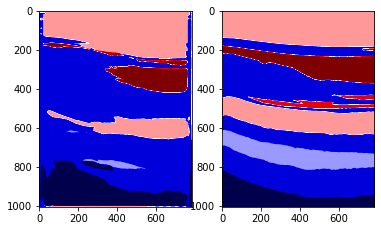

In [22]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(pred_small_40[:,:,150],cmap='seismic')

axs[1].imshow(y_test[:,:,150],cmap='seismic')
plt.show()

In [31]:
print(np.unique(pred_small))

[1 2 3 4 5 6]


In [35]:
pred_00 = np.load('prediction_first_zero.npz', allow_pickle=True, mmap_mode='r')
pred_90 = np.load('prediction.npz', allow_pickle=True, mmap_mode='r')

In [36]:
pred_00 = pred_00['prediction']
pred_90 = pred_90['prediction']

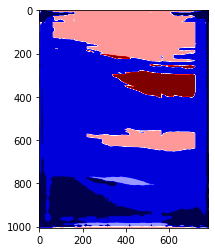

In [36]:
plt.imshow(pred_small[:,:,150],cmap='seismic')


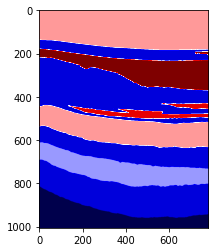

In [35]:
plt.imshow(y_test[:,:,150],cmap='seismic')